In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Data Loading

In [2]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"asteroid-db-456716-293f05c1ded7.json"

from google.cloud import bigquery
client = bigquery.Client(project="asteroid-db-456716")

query = """
SELECT *
FROM `asteroid-db-456716.exoplanet_habitability_db.join_pl_star`
"""

df = client.query(query).to_dataframe()

In [3]:
df

,planet_id,planet_name,mass,radius,density,t_eq,flux,distance_to_star,period,habitable_score,star_name,temperature,st_rad,st_mass,st_metalicity,st_lum,st_spectral_type,st_subclass
0,11COMB11COM,11 Com b,776.132328,12.200000,14.900000,810.0,419.601461,1.178000,323.210000,0.0,11 Com,4874.0,13.7600,2.090,-0.2600,1.97823,G,8.00
1,HD145675C14HER,HD 145675 c,1597.087745,12.900000,4.090000,810.0,419.601461,11.924000,15732.458890,0.0,14 Her,5338.0,0.9300,0.910,0.4052,-0.15273,K,0.00
2,14HERB14HER,14 Her b,2559.472162,12.600000,7.030000,810.0,419.601461,2.774000,1765.038900,0.0,14 Her,5338.0,0.9300,0.910,0.4052,-0.15273,K,0.00
3,24BOOB24BOO,24 Boo b,776.132328,13.900000,0.574000,810.0,419.601461,0.194000,30.330000,0.0,24 Boo,4816.0,12.1900,1.050,-0.7800,1.87691,G,3.00
4,KEPLER451C2MASSJ193832604603591,Kepler-451 c,776.132328,13.500000,1.140000,810.0,419.601461,3.103854,1460.000000,0.0,2MASS J19383260+4603591,29564.0,0.2030,0.480,-0.0920,1.45000,B,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5921,KEPLER95BKEPLER95,Kepler-95 b,13.000000,3.420000,1.710000,927.0,178.832000,0.102320,11.523100,0.0,Kepler-95,5699.0,1.4100,1.080,0.3000,0.28105,G,0.00
5922,TOI1685BTOI1685,TOI-1685 b,3.030000,1.468000,5.300000,1062.0,236.000000,0.011380,0.669139,0.0,TOI-1685,3575.0,0.4555,0.454,0.3000,-1.51542,M,2.65
5923,TOI2373BTOI2373,TOI-2373 b,2955.804185,10.424352,14.400000,860.0,69.872600,0.112000,13.336680,0.0,TOI-2373,5651.0,1.1020,1.041,0.3000,0.05115,G,0.00
5924,TOI2714BTOI2714,TOI-2714 b,228.000000,13.720000,0.490000,1603.0,945.550000,0.036000,2.499387,0.0,TOI-2714,5665.0,1.2500,1.070,0.3000,0.16017,G,0.00


In [4]:
df.to_csv("modified_data.csv", index=False)

In [5]:
df["isHabitable"] = (df["habitable_score"] > 0.7).astype(int)

In [6]:
df["isHabitable"].value_counts()

isHabitable
0    5856
1      70
Name: count, dtype: int64

In [7]:
df_numeric = df.select_dtypes(include=["int64", "float64"])

corr = df_numeric.corr()

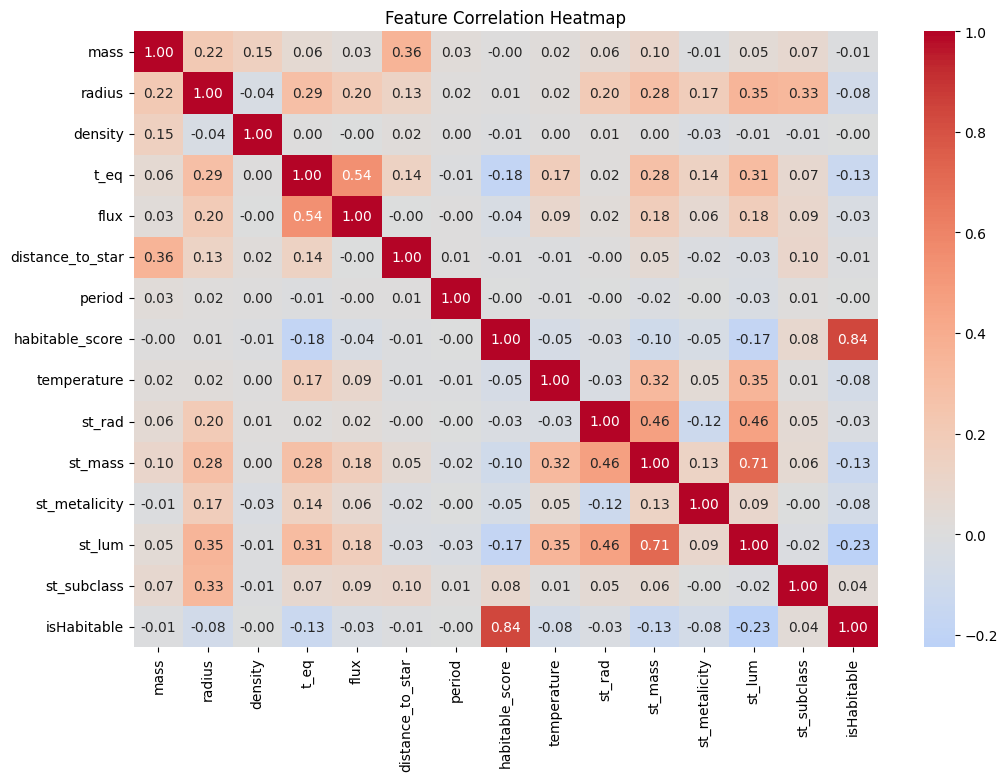

In [8]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,        # hiện số
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Engineering

In [9]:
df["log_mass"] = np.log1p(df["mass"])
df["log_radius"] = np.log1p(df["radius"])
df["log_flux"] = np.log1p(df["flux"])
df["log_st_lum"] = np.log1p(df["st_lum"])

df["flux_diff_earth"] = abs(df["flux"] - 1)
df["flux_in_hz"] = ((df["flux"] > 0.75) & (df["flux"] < 1.5)).astype(int)

df["temp_diff_earth"] = abs(df["t_eq"] - 288)
df["temp_in_hz"] = ((df["t_eq"] > 240) & (df["t_eq"] < 320)).astype(int)

C:\Users\ACER\Documents\Python\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\ACER\Documents\Python\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


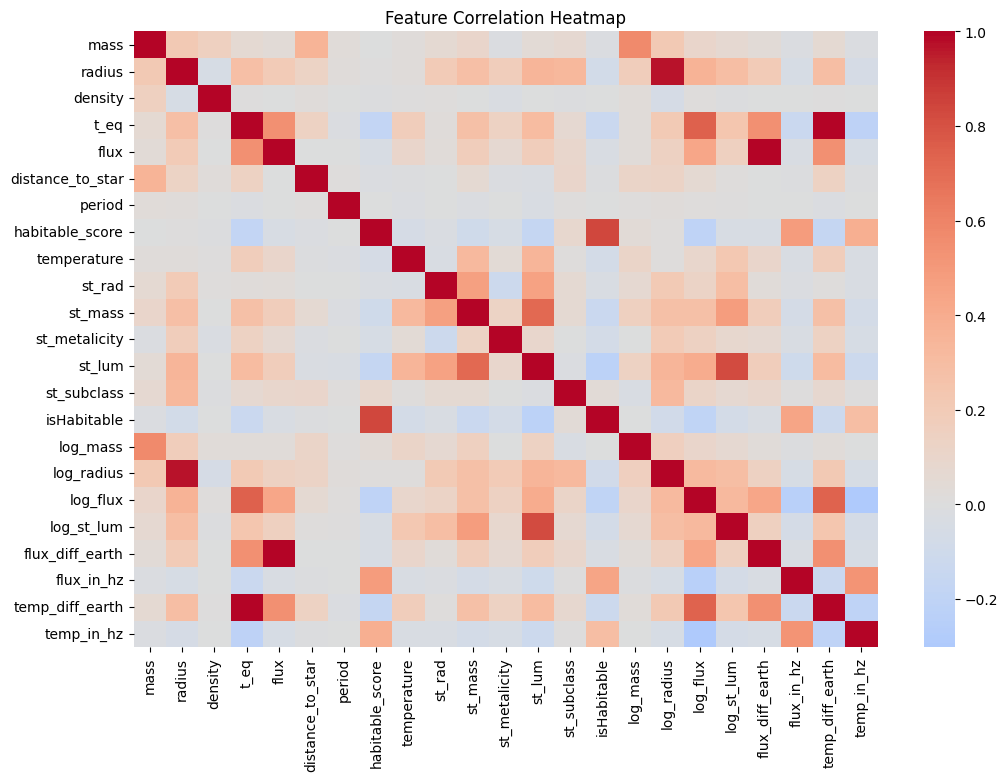

In [10]:
df_numeric = df.select_dtypes(include=["int64", "float64"])
corr = df_numeric.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,    
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
features = [
    "log_flux",
    "flux_diff_earth",
    "temp_diff_earth",
    "temp_in_hz",
    "density",
    "st_mass",
    "distance_to_star"
]

X = df[features]
X = pd.get_dummies(X, drop_first=True)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
y = df["isHabitable"]

Feature selection was performed based on correlation analysis and domain knowledge.

Highly correlated features were removed to avoid multicollinearity. 
For example, raw features such as flux and equilibrium temperature were replaced with engineered features like log_flux, flux_diff_earth, and temp_diff_earth.

Features strongly associated with planetary habitability, such as temp_in_hz and flux_diff_earth, were retained.

The final feature set includes both physical and engineered features that capture the thermal environment, stellar influence, and planetary characteristics.

## Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3333333333333,
    random_state=42,
    stratify=y
)

### XGBoost + StratifiedKFold

In [13]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos * 0.5

xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"
)

param_dist_xgb = {
    "n_estimators": [100, 200, 300, 400, 500, 700],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="recall",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)

print("Best Score:", random_search_xgb.best_score_)
print("Best Params:", random_search_xgb.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Score: 0.8777777777777779
Best Params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [14]:
best_model_xgb = random_search_xgb.best_estimator_

y_pred_xgb = best_model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1953
           1       0.57      0.87      0.69        23

    accuracy                           0.99      1976
   macro avg       0.78      0.93      0.84      1976
weighted avg       0.99      0.99      0.99      1976

[[1938   15]
 [   3   20]]


### RandomForrest + StratifiedKFold

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score


rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_dist_rf = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [None, 3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=40,
    scoring="recall",   
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

print("Best RF Score:", random_search_rf.best_score_)
print("Best RF Params:", random_search_rf.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF Score: 0.8755555555555554
Best RF Params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 3, 'bootstrap': False}


In [16]:
best_rf = random_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1953
           1       0.22      0.87      0.36        23

    accuracy                           0.96      1976
   macro avg       0.61      0.92      0.67      1976
weighted avg       0.99      0.96      0.97      1976

[[1884   69]
 [   3   20]]


## Evaluation

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

# Random Forest
results.append({
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf, zero_division=0)
})

# XGBoost
y_prob_xgb = random_search_xgb.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

results.append({
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "precision": precision_score(y_test, y_pred_xgb, zero_division=0),
    "recall": recall_score(y_test, y_pred_xgb, zero_division=0),
    "f1": f1_score(y_test, y_pred_xgb, zero_division=0)
})

results_df = pd.DataFrame(results)
print(results_df)

           model  accuracy  precision    recall        f1
0  Random Forest  0.963563   0.224719  0.869565  0.357143
1        XGBoost  0.990891   0.571429  0.869565  0.689655


# Model Evaluation and Comparative Analysis

Two supervised machine learning models, **Random Forest** and **Extreme Gradient Boosting (XGBoost)**, were developed to address the binary classification task of predicting planetary habitability. Model performance was evaluated using multiple metrics, including **accuracy, precision, recall, and F1-score**, with particular attention given to the challenges posed by **class imbalance**.


### Recall: Detection of Habitable Planets

Both models achieved an identical recall of **0.87**, indicating that they are equally effective in identifying a high proportion of habitable planets. From a domain-specific perspective, recall is a critical metric, as failing to identify a habitable planet represents a significant loss in scientific discovery.

A high recall value ensures that the majority of potentially habitable planets are successfully detected.

---

### Precision: Reliability of Positive Predictions

A notable difference between the models is observed in precision:

- Random Forest: **0.225**
- XGBoost: **0.571**

The substantially lower precision of the Random Forest model indicates a high rate of **false positive predictions**, meaning that many non-habitable planets are incorrectly classified as habitable. In contrast, XGBoost demonstrates a significantly improved ability to distinguish between classes, thereby reducing false positives and increasing the reliability of its predictions.

This improvement can be attributed to the differing learning strategies of the models. Random Forest employs a bagging approach with independently constructed trees, which may limit its ability to focus on complex decision boundaries associated with the minority class. Conversely, XGBoost utilizes a boosting framework that iteratively refines model predictions by prioritizing previously misclassified instances.

---

### F1-score: Balance Between Precision and Recall

The F1-score, defined as the harmonic mean of precision and recall, provides a comprehensive measure of model performance:

- Random Forest: **0.357**
- XGBoost: **0.690**

The significantly higher F1-score achieved by XGBoost indicates a superior balance between sensitivity (recall) and predictive reliability (precision). This suggests that XGBoost is more effective in identifying habitable planets while minimizing incorrect classifications.

---

## Conclusion

The results demonstrate that **XGBoost outperforms Random Forest** in the task of predicting planetary habitability. While both models achieve comparable recall, XGBoost provides significantly higher precision and F1-score, indicating a more balanced and reliable classification performance.

In particular, XGBoost is better suited for handling imbalanced data and capturing complex, non-linear relationships between features and the target variable.

Therefore, **XGBoost is selected as the final model** for this study, as it offers a superior trade-off between detecting habitable planets and minimizing false positive predictions.


In [18]:
importance = pd.Series(
    best_model_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

flux_diff_earth     0.443454
log_flux            0.255605
st_mass             0.098498
temp_diff_earth     0.071696
temp_in_hz          0.049344
density             0.044019
distance_to_star    0.037383
dtype: float32


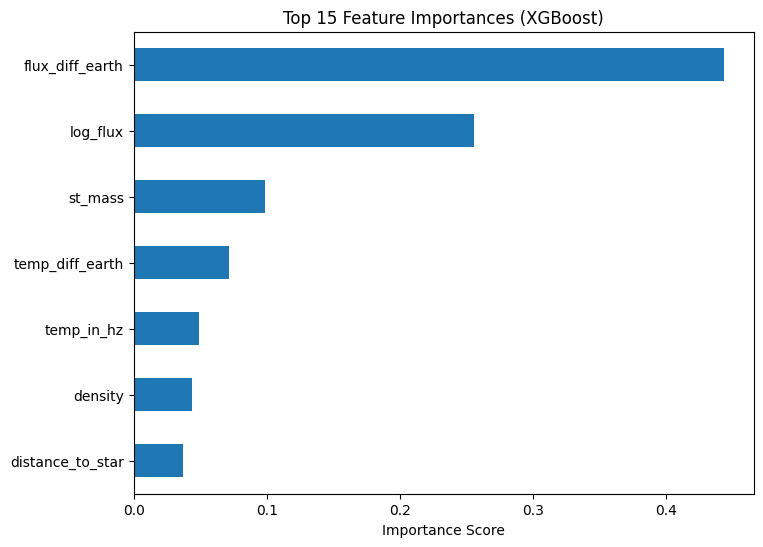

In [19]:
importance.head(15).sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.show()